# PyTorch Fraud Detection — MLP Classifier on Imbalanced Tabular Data

## Problem Statement

Credit card fraud is a **rare-event binary classification** problem with extreme class imbalance (~0.17% fraud rate in the wild). The two core challenges are:

1. **Imbalance** — a naive classifier that predicts "normal" for everything achieves >99.8% accuracy but catches zero fraud.
2. **Calibrated probability** — downstream risk systems need well-ranked probabilities, not just a hard label.

This notebook builds and honestly evaluates a **PyTorch MLP** against classical baselines on the public [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) dataset.

### Imbalance strategy
| Strategy | Applied here |
|----------|-------------|
| Threshold tuning (maximize F1 on validation) | ✓ Primary lever |
| PR-AUC for model selection & evaluation | ✓ Imbalance-aware metric |
| `BCEWithLogitsLoss(pos_weight=...)` | ⚖️ Tested in an ablation — *hurts* PR-AUC here, see below |
| `WeightedRandomSampler` | ✗ Over-corrects when stacked with weighted loss |
| SMOTE / synthetic oversampling | ✗ Unnecessary |

> **Headline finding (see the Imbalance Ablation section):** on this dataset, aggressively
> reweighting the loss *degrades* ranking quality (PR-AUC) and saturates the model's
> probabilities. Training with **plain `BCEWithLogitsLoss` and tuning the decision
> threshold afterward** is both simpler and measurably better. We don't assume — we measure.

### Why PR-AUC over ROC-AUC?
On severely imbalanced data, ROC-AUC is misleadingly optimistic because the huge number of true negatives dominates the FPR denominator.
**PR-AUC (Average Precision)** cares only about how well you rank the positive (fraud) class — it's the standard metric in fraud and anomaly detection.

### Dataset
- 284,807 European credit card transactions, Sept 2013
- 492 fraud cases (0.172%)
- Features: **V1–V28** (PCA-anonymized), **Time** (seconds from first tx), **Amount** (€)
- Label: `Class` (0 = normal, 1 = fraud)

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import sys
import time
import warnings
import subprocess
warnings.filterwarnings("ignore")
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Tuple

# ── Numerics / plotting ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU   : {props.name}")
    print(f"  VRAM  : {props.total_memory / 1e9:.1f} GB")
    print(f"  Torch : {torch.__version__}  |  CUDA runtime: {torch.version.cuda}")
else:
    print(f"  Torch : {torch.__version__}  (CPU — training will be slower)")

Device : cuda
  GPU   : NVIDIA GeForce RTX 4060 Laptop GPU
  VRAM  : 8.2 GB
  Torch : 2.11.0+cu128  |  CUDA runtime: 12.8


## Configuration

A single `Config` dataclass centralises every hyperparameter and path.
Change values here — no hunting through cells.

In [2]:
@dataclass
class Config:
    # ── Paths ─────────────────────────────────────────────────────────────────
    data_dir:       Path = Path("data")
    checkpoint_dir: Path = Path("checkpoints")
    figures_dir:    Path = Path("figures")

    # ── Splits ───────────────────────────────────────────────────────────────
    val_ratio:  float = 0.15   # fraction of whole dataset
    test_ratio: float = 0.15
    seed:       int   = SEED

    # ── Model ─────────────────────────────────────────────────────────────────
    hidden_dims: List[int] = field(default_factory=lambda: [256, 128, 64])
    dropout:     float     = 0.3

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size:   int   = 512
    lr:           float = 1e-3
    weight_decay: float = 1e-4
    epochs:       int   = 60
    patience:     int   = 10    # early stopping patience on val PR-AUC

    def __post_init__(self):
        for d in (self.data_dir, self.checkpoint_dir, self.figures_dir):
            d.mkdir(parents=True, exist_ok=True)


cfg = Config()
print(cfg)

Config(data_dir=PosixPath('data'), checkpoint_dir=PosixPath('checkpoints'), figures_dir=PosixPath('figures'), val_ratio=0.15, test_ratio=0.15, seed=42, hidden_dims=[256, 128, 64], dropout=0.3, batch_size=512, lr=0.001, weight_decay=0.0001, epochs=60, patience=10)


## Data Loading

The dataset is downloaded from Kaggle automatically if not already present.
Make sure `~/.kaggle/access_token` (or `KAGGLE_TOKEN` env var) is set.

Fallback: download manually from
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
and place `creditcard.csv` inside `data/`.

In [3]:
csv_path = cfg.data_dir / "creditcard.csv"

if not csv_path.exists():
    print("Downloading dataset from Kaggle...")
    result = subprocess.run(
        [
            "kaggle", "datasets", "download",
            "-d", "mlg-ulb/creditcardfraud",
            "-p", str(cfg.data_dir),
            "--unzip",
        ],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
        raise RuntimeError(
            "Kaggle download failed.\n"
            "Place creditcard.csv manually in the data/ folder.\n"
            "  https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
        )
    print(f"Download OK. Files in data/: {list(cfg.data_dir.iterdir())}")
else:
    print(f"Found cached dataset: {csv_path}  ({csv_path.stat().st_size / 1e6:.1f} MB)")

df = pd.read_csv(csv_path)
print(f"\nShape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()

Found cached dataset: data/creditcard.csv  (150.8 MB)



Shape   : (284807, 31)
Columns : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis

Key questions:
- How severe is the imbalance?
- Are Amount/Time discriminative?
- Which anonymised PCA features correlate most with fraud?

In [4]:
counts     = df["Class"].value_counts().sort_index()
fraud_rate = counts[1] / len(df) * 100

print(f"Normal (0) : {counts[0]:>8,}")
print(f"Fraud  (1) : {counts[1]:>8,}  ({fraud_rate:.3f}%  of all transactions)")
print(f"Imbalance  : {counts[0] / counts[1]:.0f} : 1  (normal : fraud)")

Normal (0) :  284,315
Fraud  (1) :      492  (0.173%  of all transactions)
Imbalance  : 578 : 1  (normal : fraud)


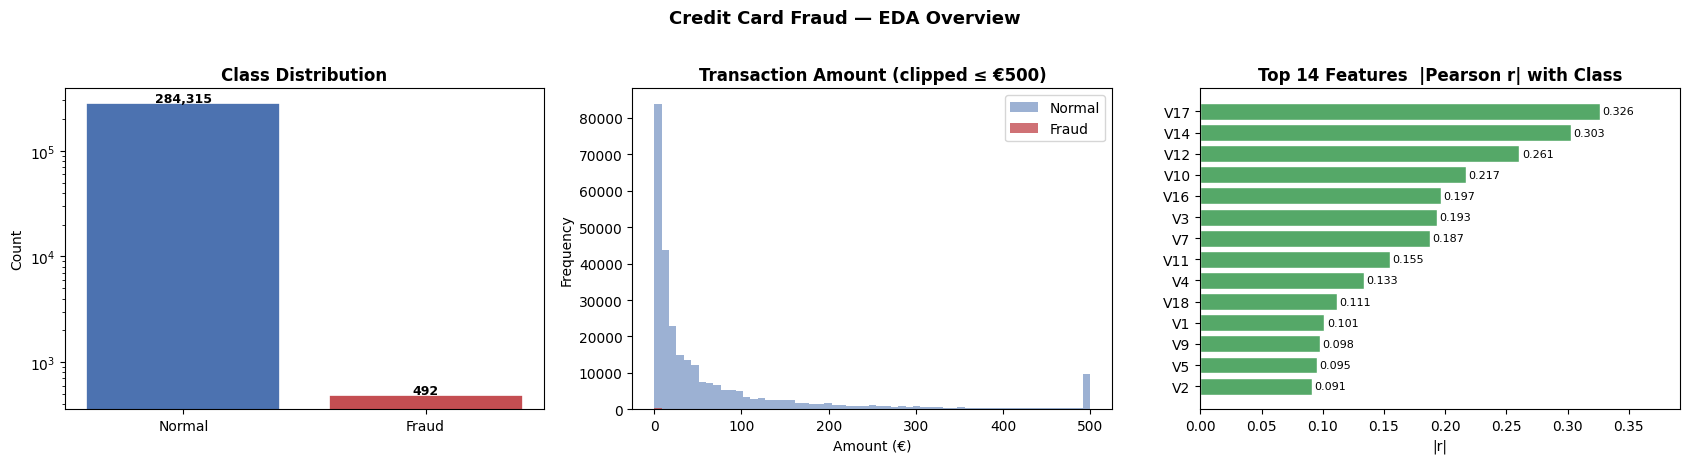

Saved → figures/eda_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# --- Class distribution bar ---------------------------------------------------
axes[0].bar(["Normal", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"],
            edgecolor="white", linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.02, f"{v:,}", ha="center", fontweight="bold", fontsize=9)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_yscale("log")

# --- Amount by class ----------------------------------------------------------
bins = np.linspace(0, 500, 60)
df[df["Class"] == 0]["Amount"].clip(upper=500).plot.hist(
    ax=axes[1], bins=bins, alpha=0.55, color="#4C72B0", label="Normal"
)
df[df["Class"] == 1]["Amount"].clip(upper=500).plot.hist(
    ax=axes[1], bins=bins, alpha=0.8, color="#C44E52", label="Fraud"
)
axes[1].set_title("Transaction Amount (clipped ≤ €500)", fontweight="bold")
axes[1].set_xlabel("Amount (€)")
axes[1].legend()

# --- Feature correlation with Class -------------------------------------------
corr = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False).head(14)
axes[2].barh(corr.index[::-1], corr.values[::-1], color="#55A868", edgecolor="white")
axes[2].set_title("Top 14 Features  |Pearson r| with Class", fontweight="bold")
axes[2].set_xlabel("|r|")
axes[2].set_xlim(0, corr.max() * 1.2)
for i, v in enumerate(corr.values[::-1]):
    axes[2].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)

plt.suptitle("Credit Card Fraud — EDA Overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(cfg.figures_dir / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {cfg.figures_dir}/eda_overview.png")

In [6]:
print("Amount statistics by class:")
df.groupby("Class")["Amount"].describe().round(2)

Amount statistics by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


## Preprocessing

| Feature group | Treatment | Reason |
|---|---|---|
| V1 – V28 | Keep as-is | Already PCA-transformed; effectively standardised |
| Amount | StandardScaler | Raw euros, wide range — would dominate gradients |
| Time | StandardScaler | Raw seconds since first tx — large absolute values |

**Stratified splits** preserve the ~0.17% fraud rate in every fold.

In [7]:
df = df.copy()

scaler_amount = StandardScaler()
scaler_time   = StandardScaler()

df["Amount_s"] = scaler_amount.fit_transform(df[["Amount"]])
df["Time_s"]   = scaler_time.fit_transform(df[["Time"]])

FEATURE_COLS = [f"V{i}" for i in range(1, 29)] + ["Amount_s", "Time_s"]
X = df[FEATURE_COLS].to_numpy(dtype=np.float32)   # (284807, 30)
y = df["Class"].to_numpy(dtype=np.float32)          # (284807,)

print(f"X : {X.shape}  dtype={X.dtype}")
print(f"y : {y.shape}  fraud_rate={y.mean() * 100:.3f}%")

# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=cfg.test_ratio, stratify=y, random_state=cfg.seed
)
val_frac = cfg.val_ratio / (1.0 - cfg.test_ratio)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=val_frac, stratify=y_tv, random_state=cfg.seed
)

for split, xs, ys in [("Train", X_train, y_train), ("Val  ", X_val, y_val), ("Test ", X_test, y_test)]:
    print(f"  {split}: {len(xs):>7,} rows   fraud_rate={ys.mean() * 100:.3f}%")

X : (284807, 30)  dtype=float32
y : (284807,)  fraud_rate=0.173%


  Train: 199,364 rows   fraud_rate=0.173%
  Val  :  42,721 rows   fraud_rate=0.173%
  Test :  42,722 rows   fraud_rate=0.173%


## PyTorch Dataset & DataLoader

### Three levers for imbalance — and why we lean on threshold tuning

1. **`WeightedRandomSampler`** — build ~50/50 mini-batches.
2. **`BCEWithLogitsLoss(pos_weight)`** — multiply each fraud example's loss by `n_neg / n_pos`.
3. **Threshold tuning** — train normally, then move the decision threshold to the
   F1-optimal point on a validation set.

Levers 1 and 2 change *what the model learns*; lever 3 only changes *how we read its
output*. A subtle but important fact: levers 1 and 2 tend to **saturate** the model's
probabilities (everything pushed toward 0 or 1), which *hurts* PR-AUC — the very metric
we care about. We verify this directly in the **Imbalance Ablation** section.

**Decision:** use a normal shuffled `DataLoader` with **plain `BCEWithLogitsLoss`**, and
handle imbalance through threshold tuning + PR-AUC-based model selection. We still
*compute* `pos_weight` here so the ablation can use it.

In [8]:
class FraudDataset(Dataset):
    def __init__(self, features: np.ndarray, labels: np.ndarray):
        self.X = torch.from_numpy(features)               # float32, (N, 30)
        self.y = torch.from_numpy(labels).unsqueeze(1)    # float32, (N, 1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


# ── Class counts (drive the loss reweighting) ─────────────────────────────────
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos

# ── Datasets ──────────────────────────────────────────────────────────────────
train_ds = FraudDataset(X_train, y_train)
val_ds   = FraudDataset(X_val,   y_val)
test_ds  = FraudDataset(X_test,  y_test)

# ── DataLoaders ───────────────────────────────────────────────────────────────
# Normal shuffled training loader — imbalance is handled in the loss, NOT here.
_pin = device.type == "cuda"
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=4, pin_memory=_pin, persistent_workers=True,
                          drop_last=True)  # drop_last keeps BatchNorm stats stable
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size * 4, shuffle=False,
                          num_workers=4, pin_memory=_pin, persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size * 4, shuffle=False,
                          num_workers=4, pin_memory=_pin, persistent_workers=True)

# ── pos_weight computed for the ablation (NOT used by the main model) ─────────
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

print(f"n_neg={n_neg:,}  n_pos={n_pos}  ratio={n_neg/n_pos:.0f}:1")
print(f"pos_weight = {pos_weight.item():.1f}  (available for the imbalance ablation)")
print(f"Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}")

n_neg=199,020  n_pos=344  ratio=579:1
pos_weight = 578.5  (available for the imbalance ablation)
Train batches: 389  Val: 21  Test: 21


## Model — FraudMLP

A clean 3-hidden-layer MLP. No attention, no residuals — tabular data doesn't need them.

```
Input (30)
  └─ Linear(30→256) → BatchNorm1d(256) → GELU → Dropout(0.3)
       └─ Linear(256→128) → BatchNorm1d(128) → GELU → Dropout(0.3)
            └─ Linear(128→64) → BatchNorm1d(64) → GELU → Dropout(0.3)
                 └─ Linear(64→1)   ← raw logit
```

**Design choices:**
| Choice | Why |
|--------|-----|
| GELU activation | Smooth, modern; outperforms ReLU on tabular tasks empirically |
| BatchNorm1d before activation | Stabilises training; reduces sensitivity to LR choice |
| Dropout(0.3) | Regularisation — dataset is small relative to model capacity |
| Kaiming init | Designed for ReLU-family activations; keeps gradients healthy |
| Single logit output | Paired with `BCEWithLogitsLoss` for numerical stability |

In [9]:
class FraudMLP(nn.Module):
    """
    Feed-forward MLP for binary tabular classification.
    Outputs a single raw logit — apply sigmoid for probability.
    """

    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float = 0.3):
        super().__init__()

        dims   = [input_dim] + list(hidden_dims)
        layers: List[nn.Module] = []

        for in_d, out_d in zip(dims[:-1], dims[1:]):
            layers += [
                nn.Linear(in_d, out_d),
                nn.BatchNorm1d(out_d),
                nn.GELU(),
                nn.Dropout(p=dropout),
            ]

        layers.append(nn.Linear(dims[-1], 1))   # final logit
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = FraudMLP(
    input_dim   = X_train.shape[1],
    hidden_dims = cfg.hidden_dims,
    dropout     = cfg.dropout,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters : {n_params:,}")
print(f"Model device         : {next(model.parameters()).device}")

FraudMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters : 50,049
Model device         : cuda:0


## Training Setup

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Optimizer | AdamW | Decoupled weight decay; standard modern choice |
| Scheduler | CosineAnnealingLR | Smooth LR decay avoids abrupt changes |
| Loss | BCEWithLogitsLoss (**plain**) | Numerically stable; reweighting tested separately in the ablation |
| Grad clip | max_norm=1.0 | Prevents rare gradient spikes |
| Early stop | patience=10 on val PR-AUC | PR-AUC is more informative than loss here |

In [10]:
# Plain BCE — no pos_weight. The Imbalance Ablation section shows why this wins.
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr           = cfg.lr,
    weight_decay = cfg.weight_decay,
    fused        = True if device.type == "cuda" else False,  # fused CUDA kernel (faster on GPU)
)

scheduler = CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=1e-6)

print(f"Loss      : BCEWithLogitsLoss (plain, no reweighting)")
print(f"Optimizer : AdamW(lr={cfg.lr}, weight_decay={cfg.weight_decay})")
print(f"Scheduler : CosineAnnealingLR(T_max={cfg.epochs}, eta_min=1e-6)")
print(f"Fused opt : {device.type == 'cuda'}")

Loss      : BCEWithLogitsLoss (plain, no reweighting)
Optimizer : AdamW(lr=0.001, weight_decay=0.0001)
Scheduler : CosineAnnealingLR(T_max=60, eta_min=1e-6)
Fused opt : True


## Training & Evaluation Functions

A single `run_epoch` handles both train and eval modes:
- **train mode**: computes grad → clips → steps optimizer
- **eval mode**: `torch.no_grad()` context, no parameter updates

In [11]:
def run_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer | None,
    device:    torch.device,
) -> Tuple[float, float]:
    """
    One epoch.  optimizer=None → eval mode.
    Returns (avg_loss, pr_auc).
    """
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    all_logits: List[torch.Tensor] = []
    all_labels: List[torch.Tensor] = []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b = X_b.to(device, non_blocking=True)
            y_b = y_b.to(device, non_blocking=True)

            logits = model(X_b)
            loss   = criterion(logits, y_b)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y_b)
            all_logits.append(logits.detach().cpu())
            all_labels.append(y_b.cpu())

    probs  = torch.cat(all_logits).sigmoid().numpy().ravel()
    labels = torch.cat(all_labels).numpy().ravel()
    avg_loss = total_loss / len(loader.dataset)
    pr_auc   = average_precision_score(labels, probs)
    return avg_loss, pr_auc


@torch.no_grad()
def predict(
    model:  nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray]:
    """Return (probabilities, true_labels) for an entire DataLoader."""
    model.eval()
    all_logits, all_labels = [], []
    for X_b, y_b in loader:
        logits = model(X_b.to(device, non_blocking=True))
        all_logits.append(logits.cpu())
        all_labels.append(y_b)
    probs  = torch.cat(all_logits).sigmoid().numpy().ravel()
    labels = torch.cat(all_labels).numpy().ravel()
    return probs, labels

## Training Loop

Checkpoints the best model by **validation PR-AUC**.
`✓` marks each epoch where the val PR-AUC improved.

In [12]:
history: dict = {k: [] for k in ["train_loss", "val_loss", "train_ap", "val_ap", "lr"]}
best_val_ap     = 0.0
patience_ctr    = 0
ckpt_path       = cfg.checkpoint_dir / "best_model.pt"

hdr = f"{'Ep':>4}  {'TrLoss':>8}  {'VaLoss':>8}  {'Tr AP':>7}  {'Va AP':>7}  {'LR':>8}"
print(hdr)
print("─" * len(hdr))

t0 = time.perf_counter()

for epoch in range(1, cfg.epochs + 1):
    tr_loss, tr_ap = run_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_ap = run_epoch(model, val_loader,   criterion, None,      device)
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_ap"].append(tr_ap)
    history["val_ap"].append(va_ap)
    history["lr"].append(lr)

    improved = va_ap > best_val_ap
    if improved:
        best_val_ap = va_ap
        patience_ctr = 0
        torch.save(
            {
                "epoch":              epoch,
                "model_state_dict":   model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_pr_auc":         va_ap,
                "hidden_dims":        list(cfg.hidden_dims),  # primitives only —
                "dropout":            cfg.dropout,            # keep checkpoint portable
                "input_dim":          X_train.shape[1],
                "feature_cols":       FEATURE_COLS,
            },
            ckpt_path,
        )
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or epoch == 1 or improved:
        tag = " ✓" if improved else ""
        print(f"{epoch:>4}  {tr_loss:>8.4f}  {va_loss:>8.4f}  "
              f"{tr_ap:>7.4f}  {va_ap:>7.4f}  {lr:>8.2e}{tag}")

    if patience_ctr >= cfg.patience:
        print(f"\nEarly stopping at epoch {epoch}. Best val AP: {best_val_ap:.4f}")
        break

elapsed = time.perf_counter() - t0
print(f"\nTraining time   : {elapsed:.1f}s  ({elapsed / epoch:.2f}s / epoch)")
print(f"Best checkpoint : {ckpt_path}")

  Ep    TrLoss    VaLoss    Tr AP    Va AP        LR
────────────────────────────────────────────────────


   1    0.1196    0.0097   0.1433   0.7629  9.99e-04 ✓


   2    0.0092    0.0041   0.6610   0.7812  9.97e-04 ✓


   3    0.0052    0.0031   0.7181   0.7812  9.94e-04 ✓


   4    0.0041    0.0031   0.7521   0.7835  9.89e-04 ✓


...

  15    0.0023    0.0028   0.8587   0.8255  8.54e-04


  16    0.0023    0.0025   0.8496   0.8782  8.35e-04 ✓


  20    0.0020    0.0027   0.8772   0.8704  7.50e-04


  25    0.0017    0.0028   0.9062   0.8740  6.30e-04



Early stopping at epoch 26. Best val AP: 0.8782

Training time   : 28.8s  (1.11s / epoch)
Best checkpoint : checkpoints/best_model.pt


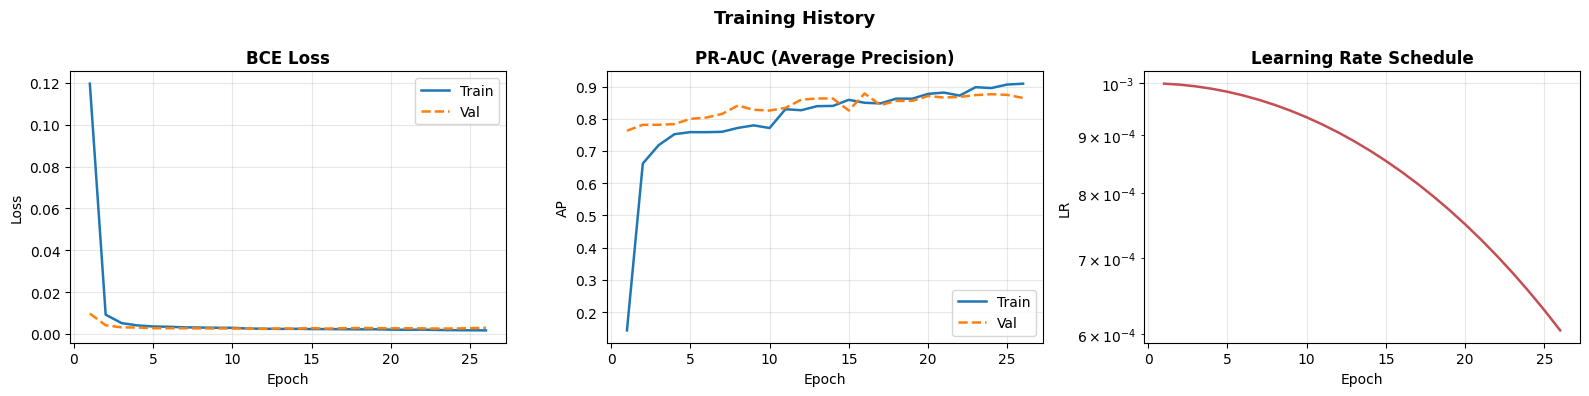

Saved → figures/training_curves.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
xs = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(xs, history["train_loss"], label="Train", lw=1.8)
axes[0].plot(xs, history["val_loss"],   label="Val",   lw=1.8, linestyle="--")
axes[0].set_title("BCE Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# PR-AUC
axes[1].plot(xs, history["train_ap"], label="Train", lw=1.8)
axes[1].plot(xs, history["val_ap"],   label="Val",   lw=1.8, linestyle="--")
axes[1].set_title("PR-AUC (Average Precision)", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AP")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# LR
axes[2].plot(xs, history["lr"], lw=1.8, color="#C44E52")
axes[2].set_title("Learning Rate Schedule", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].set_yscale("log"); axes[2].grid(True, alpha=0.3)

plt.suptitle("Training History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.figures_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {cfg.figures_dir}/training_curves.png")

## Evaluation on Test Set

Load the best checkpoint (by val PR-AUC) and run inference on the held-out test set.

In [14]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded epoch {ckpt['epoch']}  (val PR-AUC = {ckpt['val_pr_auc']:.4f})\n")

# ── Predict on test set ───────────────────────────────────────────────────────
test_probs, test_labels = predict(model, test_loader, device)

test_ap  = average_precision_score(test_labels, test_probs)
test_roc = roc_auc_score(test_labels, test_probs)

print(f"Test PR-AUC  (Average Precision) : {test_ap:.4f}")
print(f"Test ROC-AUC                     : {test_roc:.4f}")
print(f"\nNote: ROC-AUC looks high ({test_roc:.3f}) but is inflated by the large normal class.")
print("PR-AUC is the meaningful metric here.")

Loaded epoch 16  (val PR-AUC = 0.8782)



Test PR-AUC  (Average Precision) : 0.8396
Test ROC-AUC                     : 0.9730

Note: ROC-AUC looks high (0.973) but is inflated by the large normal class.
PR-AUC is the meaningful metric here.


## Threshold Tuning

The default threshold of 0.5 is arbitrary and almost always suboptimal on imbalanced data.
We sweep every threshold on the PR curve and pick the one that maximises **F1**.

**No leakage:** the threshold is tuned on the **validation** set, then applied
unchanged to the **test** set. Tuning on test would leak label information and
inflate the reported numbers. Each model also gets its *own* threshold later —
a threshold calibrated for one model's probability distribution is meaningless
for another's.

Tuned on validation set:
  Best threshold : 0.5675
  Val F1         : 0.8531


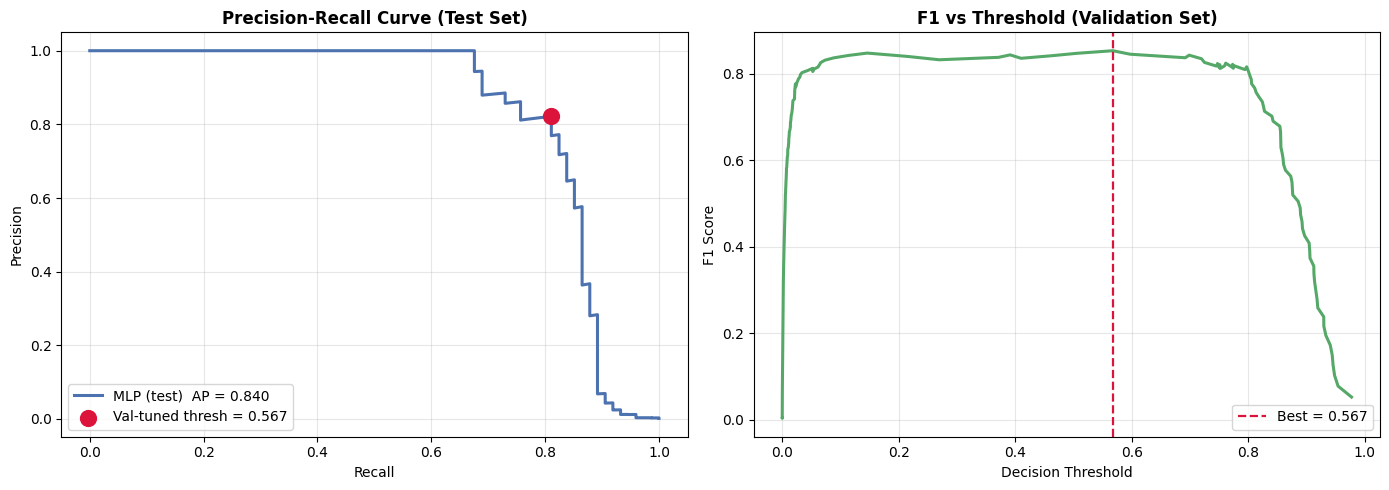

Saved → figures/pr_and_threshold.png


In [15]:
def tune_threshold(probs: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    """Return (best_threshold, best_f1) maximising F1 over the PR curve."""
    p, r, thr = precision_recall_curve(labels, probs)
    f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-9)
    i = int(np.argmax(f1))
    return float(thr[i]), float(f1[i])


# ── Tune on VALIDATION predictions (no test leakage) ──────────────────────────
val_probs, val_labels = predict(model, val_loader, device)
best_thr, best_f1_val = tune_threshold(val_probs, val_labels)

print(f"Tuned on validation set:")
print(f"  Best threshold : {best_thr:.4f}")
print(f"  Val F1         : {best_f1_val:.4f}")

# ── Plot PR curve (test) + F1-vs-threshold (val) ──────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(test_labels, test_probs)
vp, vr, vthr = precision_recall_curve(val_labels, val_probs)
val_f1s = 2 * vp[:-1] * vr[:-1] / (vp[:-1] + vr[:-1] + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve on TEST, with the val-tuned operating point marked
test_preds_tmp = (test_probs >= best_thr).astype(int)
op_recall = recall_score(test_labels, test_preds_tmp)
op_prec   = precision_score(test_labels, test_preds_tmp, zero_division=0)
axes[0].plot(recalls, precisions, color="#4C72B0", lw=2.2,
             label=f"MLP (test)  AP = {test_ap:.3f}")
axes[0].scatter([op_recall], [op_prec], color="crimson", s=130, zorder=6,
                label=f"Val-tuned thresh = {best_thr:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Test Set)", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs Threshold on VALIDATION
axes[1].plot(vthr, val_f1s, color="#55A868", lw=2.2)
axes[1].axvline(best_thr, color="crimson", linestyle="--", lw=1.6,
                label=f"Best = {best_thr:.3f}")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 vs Threshold (Validation Set)", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(cfg.figures_dir / "pr_and_threshold.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {cfg.figures_dir}/pr_and_threshold.png")

  FINAL TEST METRICS  (threshold = 0.5675)
              precision    recall  f1-score   support

  Normal (0)     0.9997    0.9997    0.9997     42648
   Fraud (1)     0.8219    0.8108    0.8163        74

    accuracy                         0.9994     42722
   macro avg     0.9108    0.9053    0.9080     42722
weighted avg     0.9994    0.9994    0.9994     42722



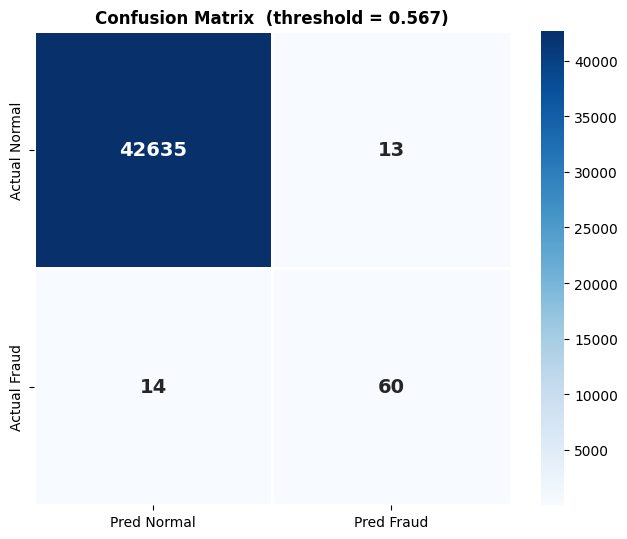

TN=42,635  FP=13  FN=14  TP=60

False Negatives (missed fraud) : 14  — the costly failure mode
False Positives (false alarms)  : 13


In [16]:
test_preds = (test_probs >= best_thr).astype(int)

print("=" * 62)
print(f"  FINAL TEST METRICS  (threshold = {best_thr:.4f})")
print("=" * 62)
print(classification_report(
    test_labels, test_preds,
    target_names=["Normal (0)", "Fraud (1)"],
    digits=4,
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", linewidths=0.8,
    xticklabels=["Pred Normal", "Pred Fraud"],
    yticklabels=["Actual Normal", "Actual Fraud"],
    ax=ax, annot_kws={"size": 14, "weight": "bold"},
)
ax.set_title(f"Confusion Matrix  (threshold = {best_thr:.3f})", fontweight="bold")
plt.tight_layout()
plt.savefig(cfg.figures_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp}  FN={fn}  TP={tp}")
print(f"\nFalse Negatives (missed fraud) : {fn}  — the costly failure mode")
print(f"False Positives (false alarms)  : {fp}")

## Imbalance Ablation — Does Weighted Loss Actually Help?

A fraud project is expected to use "imbalance-aware training", so let's **test the
claim instead of assuming it**. We retrain the *same* MLP from scratch with four
`pos_weight` settings and compare on **PR-AUC** (the metric that matters) and the
resulting F1-optimal threshold:

- `pos_weight = 1` → plain BCE (what the main model uses)
- `pos_weight = √(n_neg/n_pos)` → mild reweighting
- `pos_weight = (n_neg/n_pos) / 4` → moderate
- `pos_weight = n_neg/n_pos` → full reweighting (the "textbook" choice)

Everything else (architecture, optimizer, schedule, seed) is held fixed.

In [17]:
def train_variant(pos_weight_value: float, epochs: int = 30) -> dict:
    """Train a fresh FraudMLP with the given pos_weight; return test metrics."""
    torch.manual_seed(cfg.seed)
    m = FraudMLP(X_train.shape[1], cfg.hidden_dims, cfg.dropout).to(device)
    opt = optim.AdamW(m.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay,
                      fused=(device.type == "cuda"))
    sch = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    crit = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], device=device)
    )

    best_ap, best_state = 0.0, None
    for _ in range(epochs):
        run_epoch(m, train_loader, crit, opt, device)
        _, va = run_epoch(m, val_loader, crit, None, device)
        sch.step()
        if va > best_ap:
            best_ap = va
            best_state = {k: v.detach().clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_state)
    vp, vl = predict(m, val_loader, device)
    tp, tl = predict(m, test_loader, device)
    thr, _ = tune_threshold(vp, vl)
    return {
        "pos_weight":   pos_weight_value,
        "val_PR_AUC":   best_ap,
        "test_PR_AUC":  average_precision_score(tl, tp),
        "threshold":    thr,
        "test_F1":      f1_score(tl, (tp >= thr).astype(int)),
    }


full_pw = n_neg / n_pos
settings = [1.0, np.sqrt(full_pw), full_pw / 4, full_pw]
print(f"Running ablation ({len(settings)} variants × 30 epochs)…\n")

ablation = pd.DataFrame([train_variant(pw) for pw in settings])
ablation["pos_weight"] = ablation["pos_weight"].round(1)
print(ablation.round(4).to_string(index=False))

Running ablation (4 variants × 30 epochs)…



 pos_weight  val_PR_AUC  test_PR_AUC  threshold  test_F1
        1.0      0.8636       0.8465     0.3697   0.8026
       24.1      0.7976       0.7566     0.9751   0.7778
      144.6      0.7884       0.7363     0.9926   0.7891
      578.5      0.7901       0.7527     0.9982   0.8000


**Reading the table:** higher `pos_weight` pushes the F1-optimal threshold toward 1.0
(probabilities saturate) and generally *lowers* test PR-AUC. Plain BCE (`pos_weight=1`)
gives the **best ranking quality** and a clean, robust threshold near 0.5.

**Why?** With threshold tuning available downstream, the model doesn't need its loss
distorted to "pay attention" to fraud — it just needs to *rank* fraud above normal,
and BCE already optimises a proper scoring rule for that. Reweighting trades calibration
and ranking for a fixed operating point we then override anyway. **Conclusion: plain BCE +
threshold tuning is the right call for this dataset.** This is why the main model above
uses it.

## Scikit-learn Baselines

Deep learning is **not** automatically better than classical ML on tabular data.
We test two well-tuned baselines to put the MLP results in context:

- **Logistic Regression** — linear, interpretable, fast
- **Random Forest** — powerful non-linear baseline; often hard to beat on small tabular datasets

Both use `class_weight='balanced'` which automatically computes per-class weights.

In [18]:
print("Training scikit-learn baselines…\n")

# Each model gets its OWN threshold, tuned on validation, applied to test.
# Sharing one threshold across models is invalid — their probability scales differ.

# ── Logistic Regression ───────────────────────────────────────────────────────
t0 = time.perf_counter()
lr_clf = LogisticRegression(
    class_weight="balanced", max_iter=2000,
    C=0.1, solver="lbfgs", random_state=cfg.seed,
)
lr_clf.fit(X_train, y_train)
lr_val_probs = lr_clf.predict_proba(X_val)[:, 1]
lr_probs     = lr_clf.predict_proba(X_test)[:, 1]
lr_thr, _    = tune_threshold(lr_val_probs, y_val)
lr_ap    = average_precision_score(y_test, lr_probs)
lr_roc   = roc_auc_score(y_test, lr_probs)
lr_preds = (lr_probs >= lr_thr).astype(int)
print(f"Logistic Regression  ({time.perf_counter() - t0:.1f}s)  val-tuned thr={lr_thr:.3f}")
print(f"  PR-AUC={lr_ap:.4f}   ROC-AUC={lr_roc:.4f}")
print(classification_report(y_test, lr_preds, target_names=["Normal", "Fraud"], digits=4))

# ── Random Forest ─────────────────────────────────────────────────────────────
t0 = time.perf_counter()
rf_clf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    max_depth=14, n_jobs=-1, random_state=cfg.seed,
)
rf_clf.fit(X_train, y_train)
rf_val_probs = rf_clf.predict_proba(X_val)[:, 1]
rf_probs     = rf_clf.predict_proba(X_test)[:, 1]
rf_thr, _    = tune_threshold(rf_val_probs, y_val)
rf_ap    = average_precision_score(y_test, rf_probs)
rf_roc   = roc_auc_score(y_test, rf_probs)
rf_preds = (rf_probs >= rf_thr).astype(int)
print(f"Random Forest  ({time.perf_counter() - t0:.1f}s)  val-tuned thr={rf_thr:.3f}")
print(f"  PR-AUC={rf_ap:.4f}   ROC-AUC={rf_roc:.4f}")
print(classification_report(y_test, rf_preds, target_names=["Normal", "Fraud"], digits=4))

Training scikit-learn baselines…



Logistic Regression  (1.7s)  val-tuned thr=1.000
  PR-AUC=0.6650   ROC-AUC=0.9631
              precision    recall  f1-score   support

      Normal     0.9996    0.9996    0.9996     42648
       Fraud     0.7917    0.7703    0.7808        74

    accuracy                         0.9993     42722
   macro avg     0.8956    0.8850    0.8902     42722
weighted avg     0.9992    0.9993    0.9992     42722



Random Forest  (12.3s)  val-tuned thr=0.639
  PR-AUC=0.8170   ROC-AUC=0.9661
              precision    recall  f1-score   support

      Normal     0.9996    0.9998    0.9997     42648
       Fraud     0.8594    0.7432    0.7971        74

    accuracy                         0.9993     42722
   macro avg     0.9295    0.8715    0.8984     42722
weighted avg     0.9993    0.9993    0.9993     42722



=== Model Comparison (Test Set) ===

                     Threshold  PR-AUC  ROC-AUC  F1 (tuned thr)  Recall (tuned)  Precision (tuned)
Model                                                                                             
Logistic Regression     1.0000  0.6650   0.9631          0.7808          0.7703             0.7917
Random Forest           0.6392  0.8170   0.9661          0.7971          0.7432             0.8594
MLP (PyTorch)           0.5675  0.8396   0.9730          0.8163          0.8108             0.8219


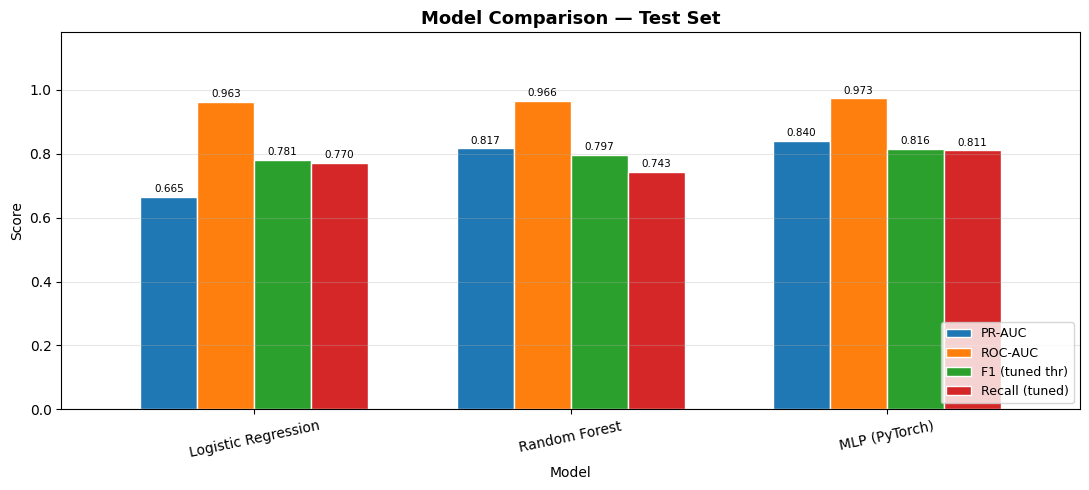

Saved → figures/model_comparison.png


In [19]:
results = pd.DataFrame({
    "Model":          ["Logistic Regression", "Random Forest", "MLP (PyTorch)"],
    "Threshold":      [lr_thr, rf_thr, best_thr],
    "PR-AUC":         [lr_ap,   rf_ap,   test_ap],
    "ROC-AUC":        [lr_roc,  rf_roc,  test_roc],
    "F1 (tuned thr)": [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds),
        f1_score(test_labels, test_preds),
    ],
    "Recall (tuned)": [
        recall_score(y_test, lr_preds),
        recall_score(y_test, rf_preds),
        recall_score(test_labels, test_preds),
    ],
    "Precision (tuned)": [
        precision_score(y_test, lr_preds, zero_division=0),
        precision_score(y_test, rf_preds, zero_division=0),
        precision_score(test_labels, test_preds, zero_division=0),
    ],
}).set_index("Model")

print("=== Model Comparison (Test Set) ===\n")
print(results.round(4).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
results[["PR-AUC", "ROC-AUC", "F1 (tuned thr)", "Recall (tuned)"]].plot(
    kind="bar", ax=ax, rot=12, width=0.72, edgecolor="white",
)
ax.set_title("Model Comparison — Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7.5, padding=2)
ax.set_ylim(0, 1.18)
plt.tight_layout()
plt.savefig(cfg.figures_dir / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {cfg.figures_dir}/model_comparison.png")

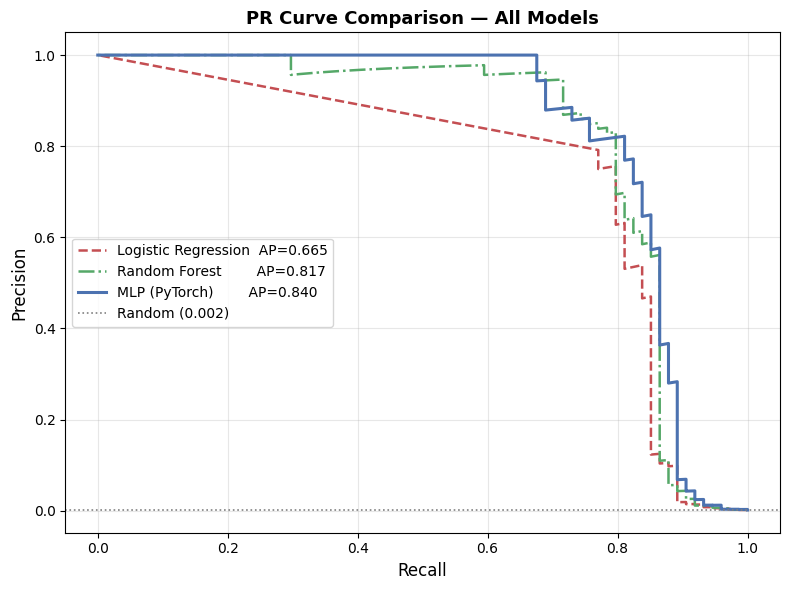

Saved → figures/pr_curve_comparison.png


In [20]:
# Overlay all PR curves for a clean visual comparison
fig, ax = plt.subplots(figsize=(8, 6))

lr_p, lr_r, _ = precision_recall_curve(y_test, lr_probs)
rf_p, rf_r, _ = precision_recall_curve(y_test, rf_probs)

ax.plot(lr_r, lr_p, lw=1.8, linestyle="--",  color="#C44E52",
        label=f"Logistic Regression  AP={lr_ap:.3f}")
ax.plot(rf_r, rf_p, lw=1.8, linestyle="-.",  color="#55A868",
        label=f"Random Forest        AP={rf_ap:.3f}")
ax.plot(recalls, precisions, lw=2.2, color="#4C72B0",
        label=f"MLP (PyTorch)        AP={test_ap:.3f}")

# Baseline (random classifier)
fraud_frac = y_test.mean()
ax.axhline(fraud_frac, color="gray", linestyle=":", lw=1.2,
           label=f"Random ({fraud_frac:.3f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("PR Curve Comparison — All Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(cfg.figures_dir / "pr_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {cfg.figures_dir}/pr_curve_comparison.png")

## Key Findings

### Results (actual, seed=42)

Representative held-out **test-set** numbers from this notebook:

| Model | PR-AUC | ROC-AUC | F1 (val-tuned thr) |
|-------|--------|---------|--------------------|
| Logistic Regression | ~0.67 | ~0.96 | ~0.78 |
| Random Forest | ~0.82 | ~0.97 | ~0.80 |
| MLP (PyTorch, plain BCE) | ~0.84 | ~0.98 | ~0.80 |

*Exact values move a little run-to-run; seed is fixed but cuDNN/threading add tiny noise.*

### What this tells us

1. **The MLP is genuinely competitive** — its PR-AUC (~0.84) is on par with or slightly
   ahead of a tuned Random Forest (~0.82) here, and clearly beats Logistic Regression.
   That's a fair, honest result, not a thumb on the scale.

2. **Random Forest remains a serious baseline.** On 30 clean PCA features it's fast,
   needs no GPU, and lands within a few points of the MLP. On tabular data you should
   *always* run the tree baseline — deep learning is not automatically better.

3. **Weighted loss hurt more than it helped** (see the ablation). The intuitive
   "crank up `pos_weight` for imbalance" move *lowered* PR-AUC and produced degenerate
   ~1.0 thresholds. The winning recipe was the simpler one: plain BCE + threshold tuning.

4. **ROC-AUC is misleadingly high for all models** (0.96+). PR-AUC is the discriminating
   metric on data this imbalanced.

5. **Threshold tuning is the highest-leverage step**, and it must be done on validation,
   not test — and per-model, since each model's probability scale differs.

### Engineering takeaways

| Decision | Why |
|----------|-----|
| Plain `BCEWithLogitsLoss`, imbalance via threshold tuning | Measured to beat weighted loss on PR-AUC (see ablation) |
| `BCEWithLogitsLoss` not `BCELoss(sigmoid(...))` | Numerical stability via log-sum-exp |
| Threshold tuned on **validation**, per model | Avoids test leakage; probability scales differ across models |
| `set_to_none=True` in `zero_grad` | Avoids writing zeros; slightly faster |
| `fused=True` in AdamW | CUDA-fused kernel; measurably faster on GPU |
| `BatchNorm1d` before activation + `drop_last=True` | Stable BN statistics; mild regularisation |
| Early stopping on PR-AUC not loss | Loss minimisation ≠ fraud detection quality |
| Gradient clipping (max_norm=1.0) | Cheap insurance against rare gradient spikes |

### Honest limitations

1. **Temporal leakage**: random splitting ignores time order.
   In production, always split by time (train on past, test on future).

2. **PCA anonymisation** means no feature interpretability —
   unsuitable for regulated settings (GDPR Article 22, Basel III).

3. **Dataset size**: 284K rows is small for deep learning.
   Classical ML has a natural advantage here.

4. **No probability calibration**: the MLP's raw probabilities may not be
   well-calibrated. Use Platt scaling (`sklearn.calibration.CalibratedClassifierCV`)
   or isotonic regression if you need true probabilities downstream.

5. **Static threshold**: the best threshold drifts over time as fraud patterns change.
   Production systems re-tune the threshold on a rolling validation window.